# Algoritmos de Boosting
Se utiliza la librería de XGBoost para implementar un algoritmo de boosting y analizar su desempeño.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
# Tratamiento de los datos
df = pd.read_csv('../dataset/star_classification.csv')
anomalias = df[(df['u'] == -9999) | (df['g'] == -9999) | (df['z'] == -9999)]

df = df[(df['u'] != -9999) & (df['g'] != -9999) & (df['z'] != -9999)]

In [3]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(df, groups=df['obj_ID']))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

X_train = train_df[features]
X_test = test_df[features]

y_train = train_df['class']
y_test = test_df['class']

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# Inicializamos XGBoost con sus hiperparámetros por defecto
xgb_clf = xgb.XGBClassifier(
    # Ensamble
    n_estimators=600,
    learning_rate=0.1,
    
    # Complejidad
    max_depth=6,
    min_child_weight=3,
    gamma=0.1,
    
    # Regularización
    reg_alpha=0.1,
    reg_lambda=1.0,
    
    # Subsampling (reduce overfitting)
    subsample=0.8,
    colsample_bytree=0.5,
    colsample_bylevel=0.8,
    
    # Otros
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    scale_pos_weight=0,
    max_delta_step=5
)
xgb_clf.fit(X_train_scaled, y_train)

# Predicciones
y_pred = xgb_clf.predict(X_test_scaled)


c:\CEIA\AMq1\ceia-amq1-tf\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:10:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Métricas de la clasificación
              precision    recall  f1-score   support

      GALAXY     0.9780    0.9851    0.9815     11815
         QSO     0.9633    0.9403    0.9517      3853
        STAR     0.9909    0.9923    0.9916      4295

    accuracy                         0.9780     19963
   macro avg     0.9774    0.9726    0.9749     19963
weighted avg     0.9779    0.9780    0.9779     19963



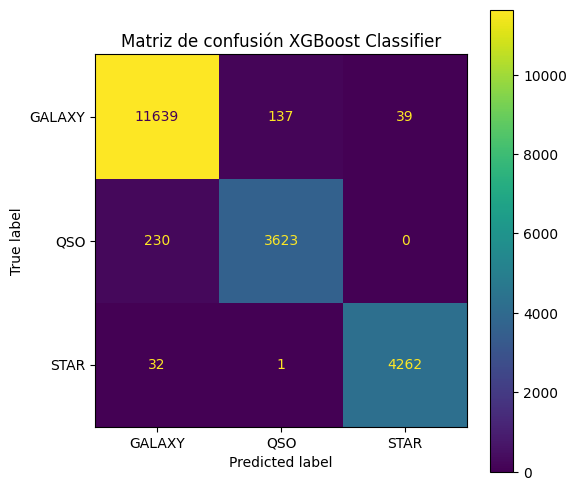

In [5]:
cm = confusion_matrix(y_test, y_pred)

disp_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.grid = False
disp_cm.plot(ax=ax)
ax.set_title("Matriz de confusión XGBoost Classifier")

print("Métricas de la clasificación")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

In [6]:
import optuna
from sklearn.model_selection import cross_val_score

In [7]:
from sklearn.utils import resample

n_samples = 80000

X_train_sub, y_train_sub = resample(
    X_train_scaled,
    y_train,
    n_samples=n_samples,
    replace=False,
    random_state=42,
    stratify=y_train
)


In [8]:
def objective(trial):
    params = {
        # Ensamble y aprendizaje
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        
        # Complejidad del árbol
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5.0),
        
        # Subsampling
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        
        # Regularización
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        
        # Fijos
        'objective': 'multi:softmax',
        'num_class': 3,
        'random_state': 42,
        'n_jobs': -1,
        'eval_metric': 'mlogloss',
    }

    clf = xgb.XGBClassifier(**params)

    scores = cross_val_score(
        clf, X_train_sub, y_train_sub,
        cv=5, scoring='accuracy', n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25, show_progress_bar=True, timeout=3600)

print("Mejores hiperparámetros encontrados:", study.best_params)
print("Mejor puntuación de validación cruzada:", study.best_value)


[I 2026-04-26 19:10:42,140] A new study created in memory with name: no-name-a6d0a29e-5d07-42f0-9bbd-e9d1b461f3c8


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-04-26 19:11:05,167] Trial 0 finished with value: 0.9691625 and parameters: {'n_estimators': 769, 'learning_rate': 0.011721551203535123, 'max_depth': 3, 'min_child_weight': 7, 'gamma': 2.9663378100911753, 'subsample': 0.745335293656766, 'colsample_bytree': 0.42506521570095235, 'reg_alpha': 0.021933235977056816, 'reg_lambda': 0.0012514997533119578}. Best is trial 0 with value: 0.9691625.
[I 2026-04-26 19:11:16,657] Trial 1 finished with value: 0.9734 and parameters: {'n_estimators': 244, 'learning_rate': 0.020349379934227346, 'max_depth': 9, 'min_child_weight': 1, 'gamma': 4.734955187401716, 'subsample': 0.7340563292874042, 'colsample_bytree': 0.5495017066702431, 'reg_alpha': 1.4950048682287749, 'reg_lambda': 0.002504001698577406}. Best is trial 1 with value: 0.9734.
[I 2026-04-26 19:11:26,336] Trial 2 finished with value: 0.97515 and parameters: {'n_estimators': 259, 'learning_rate': 0.28517490009954516, 'max_depth': 9, 'min_child_weight': 6, 'gamma': 1.7696072108408223, 'subsam

Métricas de la clasificación
              precision    recall  f1-score   support

      GALAXY     0.9780    0.9849    0.9814     11815
         QSO     0.9628    0.9403    0.9514      3853
        STAR     0.9912    0.9925    0.9919      4295

    accuracy                         0.9780     19963
   macro avg     0.9773    0.9726    0.9749     19963
weighted avg     0.9779    0.9780    0.9779     19963



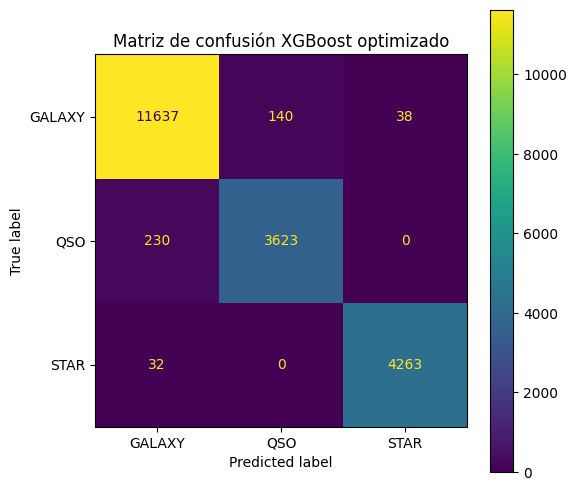

In [9]:
best_xgb = xgb.XGBClassifier(
    **study.best_params,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
best_xgb.fit(X_train_scaled, y_train)

y_pred = best_xgb.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

disp_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.grid = False
disp_cm.plot(ax=ax)
ax.set_title("Matriz de confusión XGBoost optimizado")

print("Métricas de la clasificación")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))


In [12]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [10]:
def show_metrics(y_true, y_pred, cm_classes = None, cm_title = "Matriz de confusión"):
  # Se imprimen las métricas
  cm = confusion_matrix(y_true, y_pred)

  disp_cm = ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels=cm_classes
  )

  fig, ax = plt.subplots(figsize=(6, 6))
  ax.grid = False
  disp_cm.plot(ax=ax)
  ax.set_title(cm_title)

  # Accuracy
  acc = accuracy_score(y_true, y_pred)

  # F1-score
  f1_macro = f1_score(y_true, y_pred, average='macro')
  f1_weighted = f1_score(y_true, y_pred, average='weighted')

  # Precision y Recall
  precision_macro = precision_score(y_true, y_pred, average='macro')
  recall_macro = recall_score(y_true, y_pred, average='macro')

  print("Accuracy:", acc)
  print("F1 (macro):", f1_macro)
  print("F1 (weighted):", f1_weighted)
  print("Precision (macro):", precision_macro)
  print("Recall (macro):", recall_macro)

Accuracy: 0.977959224565446
F1 (macro): 0.9749067681121253
F1 (weighted): 0.9778899729244134
Precision (macro): 0.977313943376657
Recall (macro): 0.9725967121394072


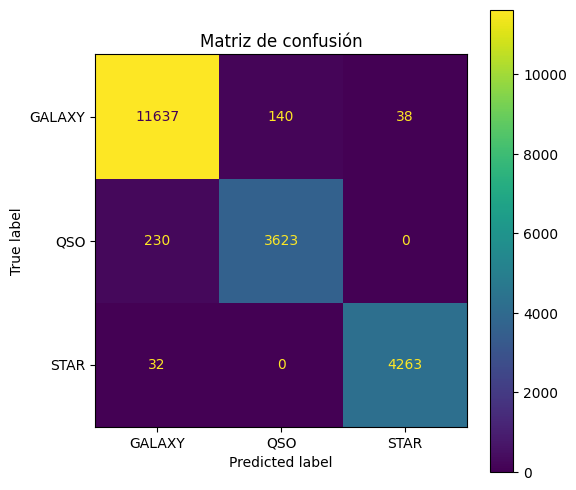

In [13]:
show_metrics(y_test, y_pred, le.classes_)